In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as s
import math as math
df = pd.read_csv("C:/Users/Manas Tiwari/Desktop/blinkit_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# convert some columns values...

In [2]:
df["Item Fat Content"]=df["Item Fat Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"})

# Q.1 : Find the total sales genrated from all item sold ??


In [5]:
a = df["Sales"].sum()
print("Total sales genrated from all item is :",a)


Total sales genrated from all item is : 1201681.4808


# Q.2 : Find the average sales genrated from all item sold ??

In [7]:
a = df["Sales"].mean()
print("Average sales genrated from all item is :",a)

Average sales genrated from all item is : 140.9927819781767


# Q.3 : Find the count of diffrent items sold ??

In [1]:
a = df["Sales"].count()
print("Total count of diffrent item sold is :",a)

# Q.4 : Find the average rating bycustomer on item sold ??

In [11]:
a = df["Rating"].mean()
a = math.ceil(a)
print("The average rating bycustomer on item sold :",a)

The average rating bycustomer on item sold : 4


# Q.5 : Find the total sales by fat content ??

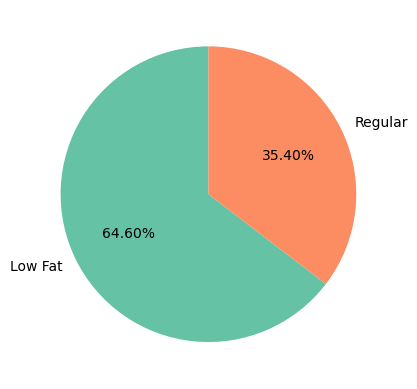

In [65]:
gp = df.groupby("Item Fat Content")["Sales"].sum()
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']
plt.pie(gp,labels = gp.index,autopct = "%1.2f%%",colors = colors,startangle = 90)
plt.show()

concusion : The majority of sales come from Low Fat items (64.6%), while Regular items account for only 35.4%—indicating a clear customer preference for healthier options.

# Q.6 : Find the total sales by item type ??

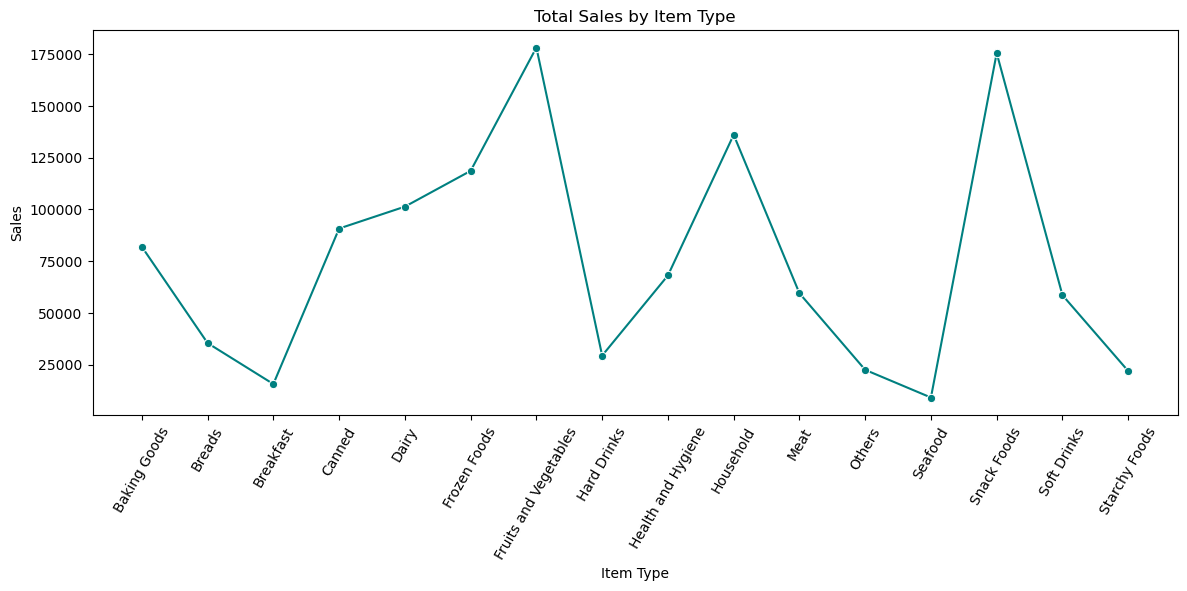

In [57]:
plt.figure(figsize = (14,5))
gp = df.groupby("Item Type")["Sales"].sum().reset_index()
s.lineplot(data=gp, x="Item Type", y="Sales",marker = "o", color="teal")
plt.xticks(rotation=60)
plt.title("Total Sales by Item Type")
plt.show()


conclusion : The highest total sales are observed in the Fruits and Vegetables and Snack Foods categories, indicating strong customer demand in these segments. In contrast, categories like Breakfast and Seafood have significantly lower sales, suggesting lesser consumer preference or limited availability.

# Q.7 : Find the fat contentby outlet for total saleas ??

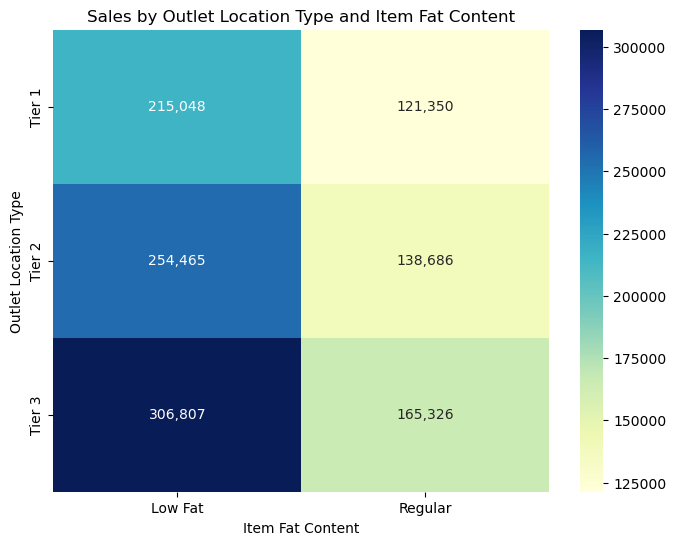

In [87]:
gp = df.groupby(["Outlet Location Type", "Item Fat Content"])["Sales"].sum().unstack()
plt.figure(figsize=(8, 6))
s.heatmap(gp, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Sales by Outlet Location Type and Item Fat Content")
plt.show()

conclusion : Sales of Low Fat items are consistently higher across all outlet location tiers compared to Regular fat items.
Tier 3 outlets lead in total sales, indicating higher consumer activity or store performance in those areas.

# Q.8 : Find the total sales by outlet establishment ??

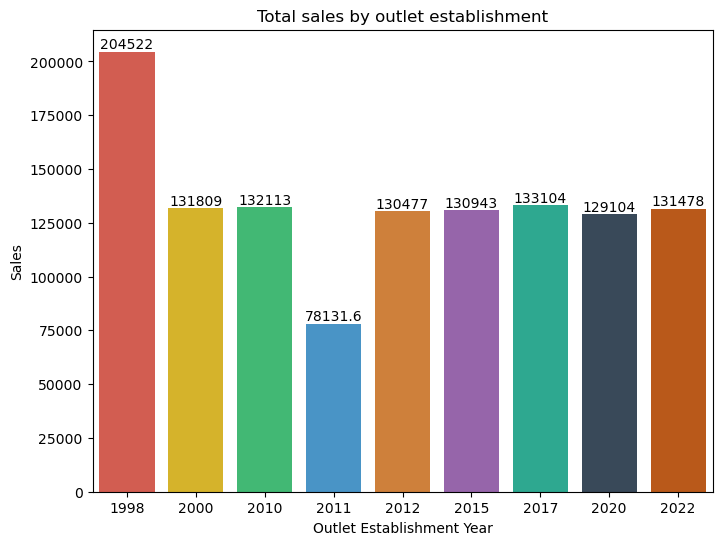

In [199]:
plt.figure(figsize=(8, 6))
colors = ['#E74C3C', '#F1C40F', '#2ECC71', '#3498DB', '#E67E22', '#9B59B6', '#1ABC9C', '#34495E', '#D35400']
gp = df.groupby("Outlet Establishment Year").agg({"Sales":"sum"})
a = s.barplot(data = gp,x = "Outlet Establishment Year",y = "Sales", palette=colors,hue="Outlet Establishment Year",legend = False ) 
for bars in a.containers:
    a.bar_label(bars)
plt.title("Total sales by outlet establishment")
plt.show()

conclusion : Outlets established in 1998 generated the highest sales, indicating strong long-term performance. In contrast, outlets from 2011 had the lowest sales, suggesting potential operational or market challenges during that period.

# Q.9 : Find the total sales by outlet size ??

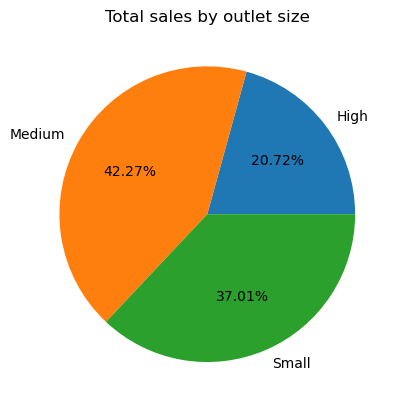

In [219]:
gp = df.groupby("Outlet Size")["Sales"].sum()
plt.pie(gp,labels = gp.index,autopct = "%1.2f%%")
plt.title("Total sales by outlet size")
plt.show()

concusion : The pie chart shows that medium-sized outlets generate the highest sales, accounting for approximately 42.27% of total sales. Small outlets follow closely with 37.01%, while high-sized outlets contribute the least at 20.72%.









# Q.10: Find the total sales by outlet location ??


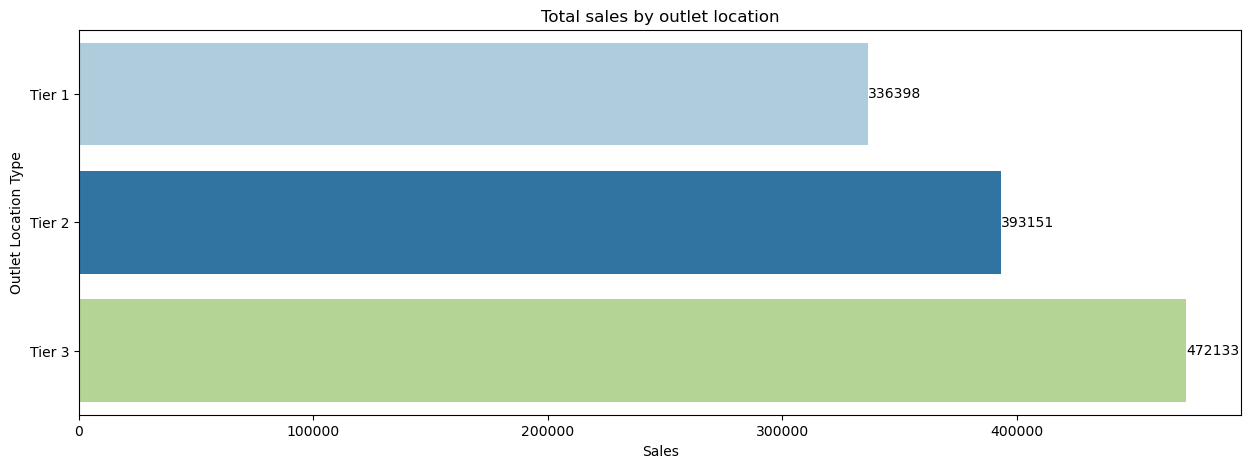

In [264]:
plt.figure(figsize=(15, 5))
gp = df.groupby("Outlet Location Type").agg({"Sales":"sum"}).reset_index()
a = s.barplot(data =gp, y = "Outlet Location Type",x = "Sales", palette= "Paired", hue = "Outlet Location Type")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Total sales by outlet location")
plt.show()

conclusion : The bar chart shows that Tier 3 outlet locations have the highest total sales, followed by Tier 2 and Tier 1.
This indicates that outlets in more developed or urbanized areas (like Tier 3) may generate more revenue..

# Final Conclusion : 

Product Preference: Customers heavily favor low-fat items, especially Fruits & Vegetables and Snack Foods, which are top contributors to total sales.

Outlet Performance: Tier 3 locations and medium-sized outlets consistently outperform others in sales, indicating better customer reach or demand in those segments.

Establishment Year Impact: Older outlets, particularly those established in 1998, tend to generate more sales, possibly due to established customer trust and wider recognition.

Sales Strategy Insight: Businesses should focus on stocking high-demand items like fruits, snacks, and low-fat products in Tier 3 and medium-sized outlets for maximum revenue.